# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_CREDIT_RECORD= Path("..") / "data" / "raw" / "credit_record.csv"          # PREENCHER: nome do arquivo
RAW_APPLICATION_RECORD= Path("..") / "data" / "raw" / "application_record.csv"     # PREENCHER: nome do arquivo
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [2]:
# Criando cópias para não modificar o DATASET principal
df_credit_record = pd.read_csv(RAW_CREDIT_RECORD)
df_application_record = pd.read_csv(RAW_APPLICATION_RECORD)

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [3]:
df_application_record.shape # Entender a dimensão do dataset

(438557, 18)

In [4]:
df_application_record.dtypes #Identifica o tipo de dados 

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
dtype: object

In [5]:
df_application_record.head(10) # buscar as 10 primeiras amostras do dataset

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0


In [6]:
df_application_record.info() # Buscar informações de non-null contagem + tipos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

### Dicionário de Dados do df_application_record
|  **Nome da Coluna**      | Tipo de Dado | Descrição / Significado |  
| :---: | :---: | :---: |
| **ID**                  | int64   | dentificador único do cliente. |  
| **CODE_GENDER**         | object  | Gênero do cliente (Ex: M/F). |  
| **FLAG_OWN_CAR**        | object  | Indica se o cliente possui carro próprio (Y/N). |  
| **FLAG_OWN_REALTY**     | object  | Indica se o cliente possui imóvel próprio (Y/N). |  
| **CNT_CHILDREN**        | int64   | Quantidade de filhos do cliente. |  
| **AMT_INCOME_TOTAL**    | float64 | Rendimento anual total do cliente. |  
| **NAME_INCOME_TYPE**    | object  | Tipo de renda (Ex: Assalariado, Pensionista, Estudante). |  
| **NAME_EDUCATION_TYPE** | object  | Grau de escolaridade (Ex: Ensino Médio, Ensino Superior). |  
| **NAME_FAMILY_STATUS**  | object  | Estado civil (Ex: Casado, Solteiro, Divorciado). |  
| **NAME_HOUSING_TYPE**   | object  | Tipo de moradia (Ex: Casa própria, Apartamento alugado). |  
| **DAYS_BIRTH**          | int64   | Idade em dias (contados regressivamente a partir de hoje. Ex:  -12000). |  
| **DAYS_EMPLOYED**       | int64   | Tempo de emprego em dias (regressivo. Se positivo, significa desempregado). |  
| **FLAG_MOBIL**          | int64   | Indica se informou telefone celular (1 = Sim, 0 = Não). |  
| **FLAG_WORK_PHONE**     | int64   | Indica se informou telefone comercial (1 = Sim, 0 = Não). |  
| **FLAG_PHONE**          | int64   | Indica se informou telefone fixo residencial (1 = Sim, 0 = Não). |  
| **FLAG_EMAIL**          | int64   | Indica se informou e-mail (1 = Sim, 0 = Não). |  
| **OCCUPATION_TYPE**     | object  | Profissão/Ocupação (Contém dados faltantes). |  
| **CNT_FAM_MEMBERS**     | float64 | Quantidade de membros na família. |  

In [7]:
df_application_record.describe() # Estatísticas numericas

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [8]:
df_application_record.describe(include='object')# Para cada coluna de texto, ele exibe quatro informações principais

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE
count,438557,438557,438557,438557,438557,438557,438557,304354
unique,2,2,2,5,5,5,6,18
top,F,N,Y,Working,Secondary / secondary special,Married,House / apartment,Laborers
freq,294440,275459,304074,226104,301821,299828,393831,78240


In [9]:
df_application_record.isnull().sum() # Buscar quantidade de elementos "null"

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [10]:
(df_application_record.isnull().sum()/ len( df_application_record)*100).round(2) # buscar quantidade de elementos "null" em porcentagem

ID                      0.0
CODE_GENDER             0.0
FLAG_OWN_CAR            0.0
FLAG_OWN_REALTY         0.0
CNT_CHILDREN            0.0
AMT_INCOME_TOTAL        0.0
NAME_INCOME_TYPE        0.0
NAME_EDUCATION_TYPE     0.0
NAME_FAMILY_STATUS      0.0
NAME_HOUSING_TYPE       0.0
DAYS_BIRTH              0.0
DAYS_EMPLOYED           0.0
FLAG_MOBIL              0.0
FLAG_WORK_PHONE         0.0
FLAG_PHONE              0.0
FLAG_EMAIL              0.0
OCCUPATION_TYPE        30.6
CNT_FAM_MEMBERS         0.0
dtype: float64

In [11]:
#Buscar se tem linhas duplicadas
df_application_record[df_application_record.duplicated(keep=False)]# Busca de valores duplicados


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS


### Depois de analisar o dataset df_Application_record
*Precisaremos tratar as variaveis mudando ['CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY'] para o tipo numerico para conseguirmos uma relação binaria.   


### E descobrir se o Outlier da variavel ['CNT_CHILDREN'] é relevante para o processamento do modelo.

In [12]:
df_credit_record.shape # Entender a dimensão do dataset

(1048575, 3)

In [13]:
df_credit_record.dtypes #Identifica o tipo de dados 

ID                 int64
MONTHS_BALANCE     int64
STATUS            object
dtype: object

In [14]:
df_credit_record.head(10) # buscar as 10 primeiras amostras do dataset

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


In [15]:
df_credit_record.info() # Buscar informações de non-null contagem + tipos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


### Dicionário de Dados do df_credit_record
|  **Nome da Coluna**      | Tipo de Dado | Descrição / Significado |  
| :---: | :---: | :---: |
| **ID**                  | int64   | Identificador único do cliente ou da conta de crédito.5001711, 5001712| 
| **MONTHS_BALANCE**      | int64   | Mês de referência dos dados em relação ao mês atual.0 (mês atual), -1 (1 mês atrás), -2 (2 meses atrás)|
| **STATUS**              | object  | Situação de pagamento da fatura ou empréstimo naquele mês.X, C, 0, 1, 2, 3, 4, 5|

*Significado dos Códigos da Coluna STATUS*  
0: Pagamento atrasado entre 1 e 29 dias.  
1: Pagamento atrasado entre 30 e 59 dias.  
2: Pagamento atrasado entre 60 e 89 dias.  
3: Pagamento atrasado entre 90 e 119 dias.  
4: Pagamento atrasado entre 120 e 149 dias.  
5: Pagamento atrasado há mais de 150 dias ou dívida baixada como prejuízo.  
C: Conta baixada/paga totalmente naquele mês (Complied/Closed).  
X: Nenhum empréstimo ou fatura ativa naquele mês.  

In [16]:
df_credit_record.describe() # Estatísticas numericas

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [17]:
df_credit_record.describe(include='object')# Para cada coluna de texto, ele exibe quatro informações principais

,STATUS
count,1048575
unique,8
top,C
freq,442031


In [18]:
df_credit_record.isnull().sum() # Buscar quantidade de elementos "null"

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [19]:
(df_credit_record.isnull().sum()/len( df_credit_record)*100).round(2) # buscar quantidade de elementos "null"em porcentagem

ID                0.0
MONTHS_BALANCE    0.0
STATUS            0.0
dtype: float64

In [20]:
df_credit_record[df_credit_record.duplicated(keep=False)] # Busca de valores duplicados

,ID,MONTHS_BALANCE,STATUS


## 2. Distribuição das variáveis

**Interpretação:** _preencher._

### Melhores Gráficos por Tipo de Dado 

**Dados Numéricos ou Contínuos (AMT_INCOME_TOTAL, DAYS_BIRTH, DAYS_EMPLOYED):**
**Histograma:** Mostra a frequência dos valores divididos em intervalos (bins).  
**KDE (Kernel Density Estimation):** Cria uma linha suave que estima a forma da distribuição.  
**Boxplot:** Ajuda a ver a mediana e identificar valores discrepantes (outliers).

**Dados Numéricos Discretos (CNT_CHILDREN, CNT_FAM_MEMBERS):**  
**Gráfico de Barras / Contagem:** Exibe exatamente quantos clientes possuem 0, 1, 2 ou mais filhos.

**Dados Categóricos (CODE_GENDER, NAME_INCOME_TYPE, NAME_EDUCATION_TYPE):**  
**Gráfico de Barras:** Compara a quantidade de registros em cada categoria de forma clara.  

### **Iniciando Com o dataframe df_application_record**

/tmp/ipykernel_40707/1849046306.py:28: MatplotlibDeprecationWarning: Support for case-insensitive scales is deprecated since 3.5 and support will be removed two minor releases later.
  axes[1].set_xscale('LOG')


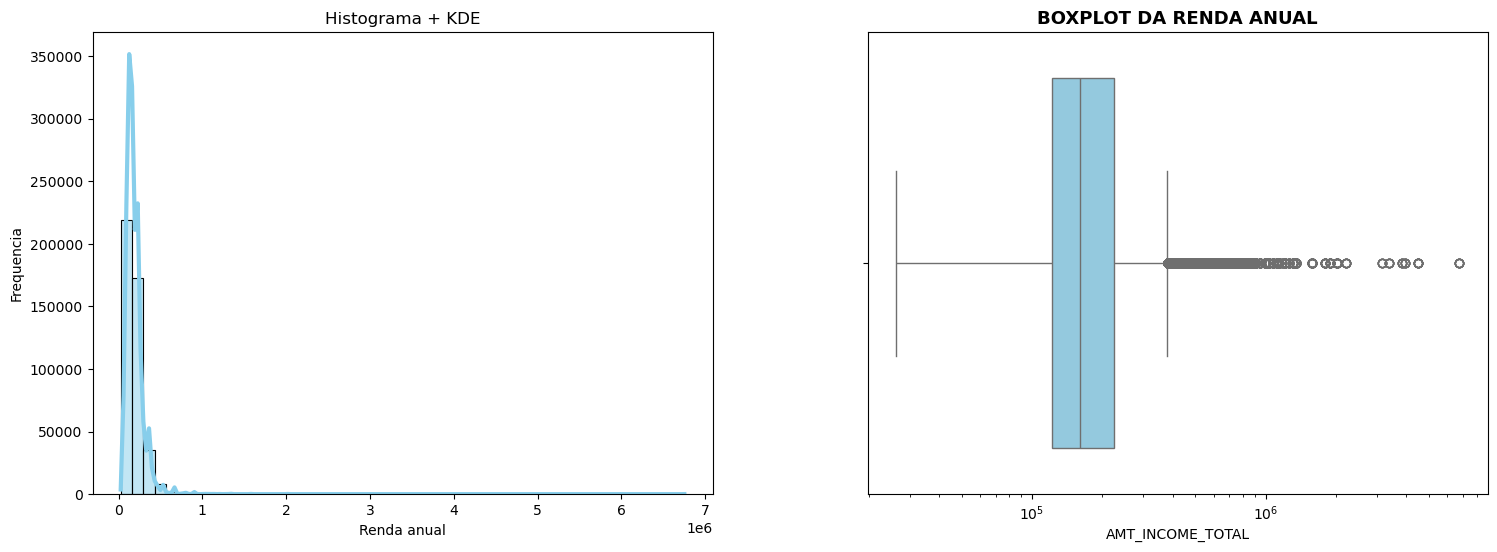

In [21]:
# Configura o tamanho do gráfico com 1 linha e 2 colunas lado a lado.
fig, axes = plt.subplots(1,2, figsize=(18,6))
plt.subplots_adjust(wspace = 0.25)# Serve para dar um espaço entre os gráficos

#Gráfico 1:Histopgrama+ kde

sns.histplot(
    data=df_application_record,
    x = "AMT_INCOME_TOTAL",
        kde = True,
        color = "skyblue",
        bins = 50,
        line_kws={'linewidth':3, 'color':'darkblue'},
        ax = axes[0]
)
axes[0].set_title("Histograma + KDE")
axes[0].set_xlabel("Renda anual")
axes[0].set_ylabel("Frequencia")

#Gráfico2 BOXPLOT
sns.boxplot(
    data = df_application_record,
    x = "AMT_INCOME_TOTAL",
    color = "skyblue",
    ax = axes[1]
)
axes[1].set_title('BOXPLOT DA RENDA ANUAL',fontsize=13,fontweight='bold')
axes[1].set_xscale('LOG')

plt.show()

### Esse gráfico tá ruim de entender
melhoria do gráfico alterando para Escala Logaritmica.

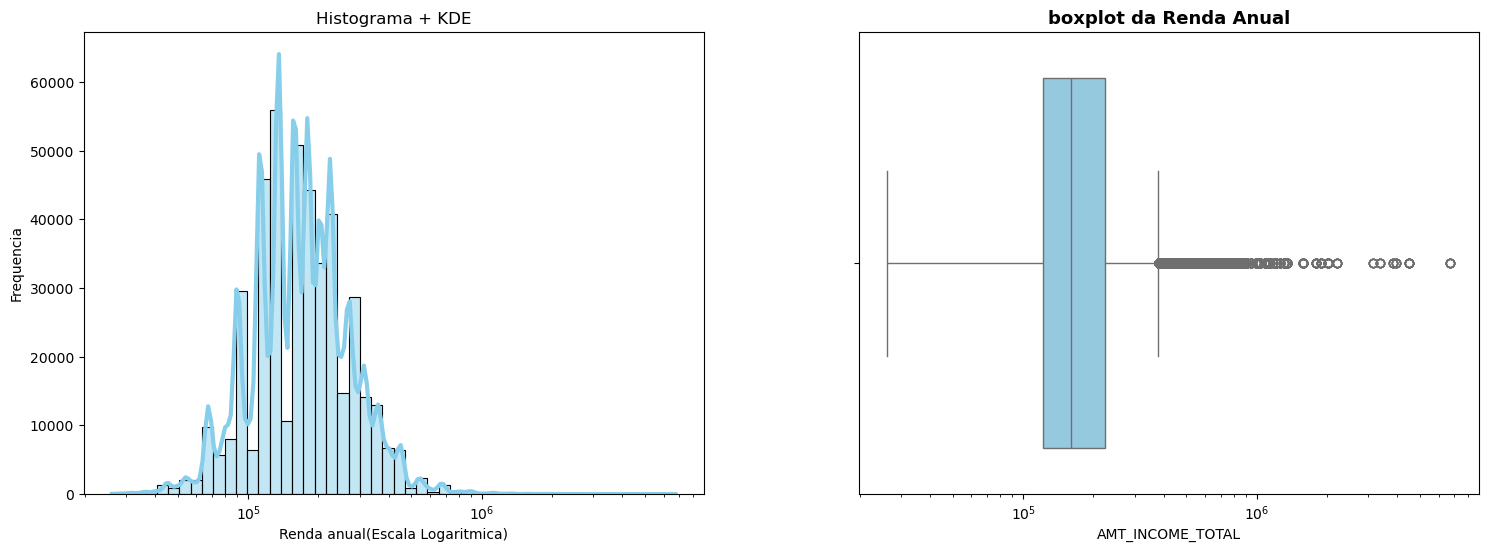

In [22]:
# Configura o tamanho  do ráfico com e linha e 2 colunas lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(18,6))
plt.subplots_adjust(wspace = 0.25)

# Gréfico 1: Histograma + KDE
sns.histplot(
    data = df_application_record,
    x = "AMT_INCOME_TOTAL",
    kde = True,
    color="skyblue",
    bins = 50,
    log_scale=True,
    line_kws={'linewidth':3, 'color': 'darkblue'},
    ax = axes[0]
)
axes[0].set_title("Histograma + KDE")
axes[0].set_xlabel("Renda anual(Escala Logaritmica)")
axes[0].set_ylabel("Frequencia")

#GRÁFICO 2 BOXPLOT
sns.boxplot(
    data = df_application_record,
    x = "AMT_INCOME_TOTAL",
    color="skyblue",
    ax = axes[1]
)
axes[1].set_title('boxplot da Renda Anual', fontsize=13,fontweight='bold')
axes[1].set_xscale('log')


# Exibe os dois gráficos na tela
plt.show()

### Analise primaria Renda Anual Total (AMT_INCOME_TOTAL):
* **Perfil do Público Alvo:** Base de clientes concentrada na classe média, com mediana de renda anual próxima a 160k.
* **Distribuição Log-Normal:** Apresenta formato de sino bem definido sob escala logarítmica, facilitando o uso em modelos lineares após a transformação.
* **Presença de Alta Renda:** Volume expressivo de outliers no topo da pirâmide (acima de 400k), exigindo atenção quanto ao risco de crédito desproporcional.

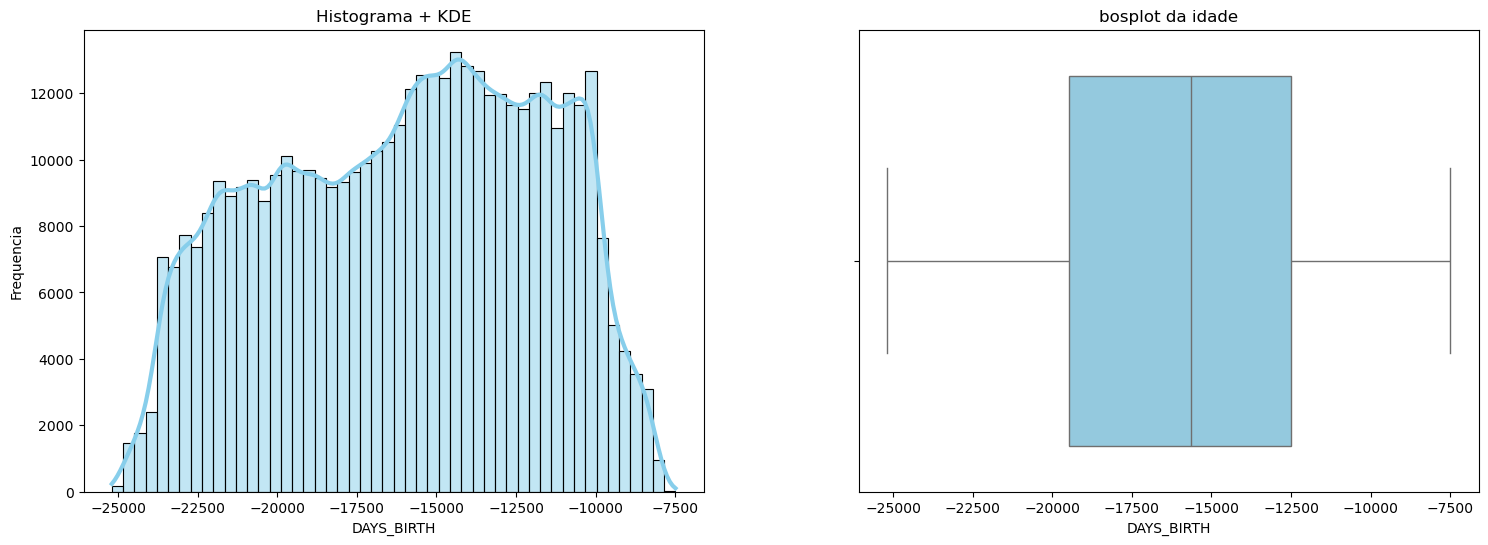

In [23]:
fig, axes = plt.subplots(1, 2, figsize = (18,6))
plt.subplots_adjust(wspace=0.25)# Ajusta da distancia entre os 2 gráficos

#solução é criar

# Gráfico 1: Histograma + KDE
sns.histplot(
    data = df_application_record,
    x= "DAYS_BIRTH",
    kde=True,
    color = 'skyblue',
    bins=50,
    line_kws={'linewidth':3, 'color': 'darkblue'},
    ax = axes[0]
)
axes[0].set_title("Histograma + KDE")
axes[0].set_xlabel("DAYS_BIRTH")
axes[0].set_ylabel("Frequencia")

#Gráfico 2 BOXPLOT  
sns.boxplot(
    data = df_application_record,
    x = "DAYS_BIRTH",
    color = "skyblue",
    ax = axes[1]
    )
axes[1].set_title('bosplot da idade')
axes[1].set_xscale('linear')
plt.show()

### Esse gráfico tá ruim de entender
melhoria do gráfico alterando dias de nascimento para anos.

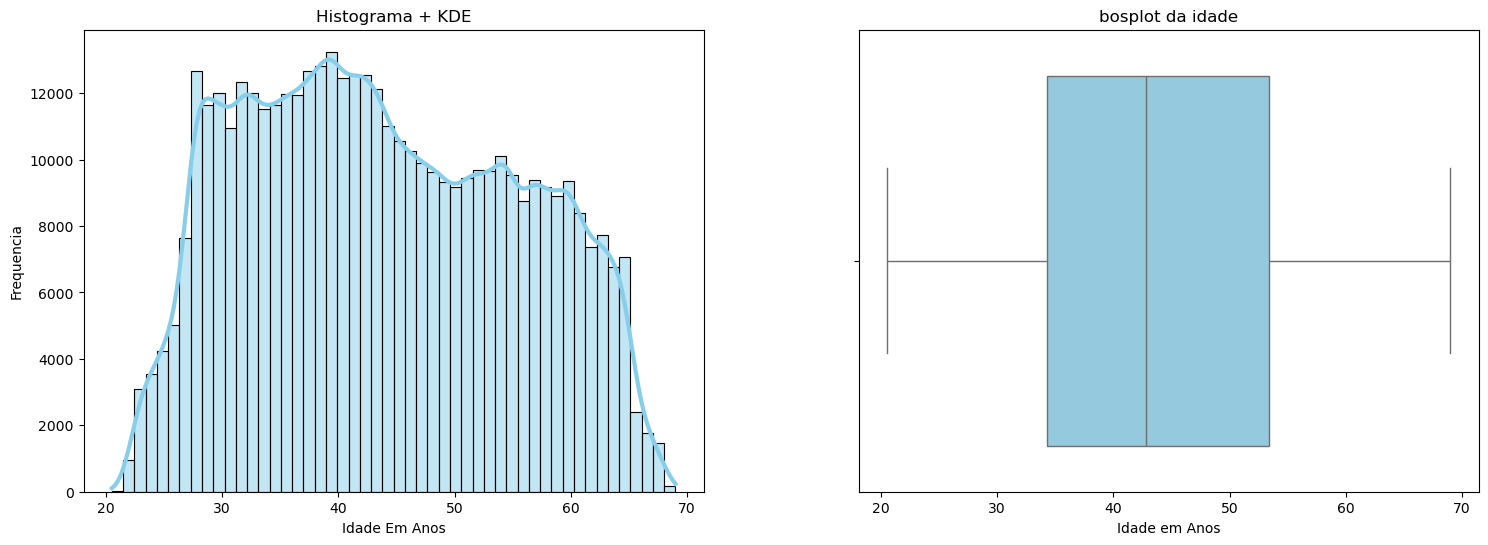

In [24]:
fig, axes = plt.subplots(1, 2, figsize = (18,6))
plt.subplots_adjust(wspace=0.25)# Ajusta da distancia entre os 2 gráficos



# Gráfico 1: Histograma + KDE
sns.histplot(
    x = -df_application_record['DAYS_BIRTH'] / 365.25,
    kde=True,
    color = 'skyblue',
    bins=50,
    line_kws={'linewidth':3, 'color': 'darkblue'},
    ax = axes[0]
)
axes[0].set_title("Histograma + KDE")
axes[0].set_xlabel("Idade Em Anos")
axes[0].set_ylabel("Frequencia")

#Gráfico 2 BOXPLOT  
sns.boxplot(
    x  = -df_application_record['DAYS_BIRTH'] / 365.25,
    color = "skyblue",
    ax = axes[1]
    )
axes[1].set_title('bosplot da idade')
axes[1].set_xlabel('Idade em Anos')
axes[1].set_xscale('linear')
plt.show()

### Analise primaria da coluna Idade dos Clientes (IDADE_ANOS):
* **Público Consolidado:** Base concentrada em adultos em idade de alta atividade econômica, com mediana de 43 anos.
* **Distribuição Equilibrada:** Grande bloco de clientes distribuído de forma homogênea entre 27 e 60 anos.
* **Dados Limpos:** Ausência de outliers ou inconsistências de dados na variável de idade.

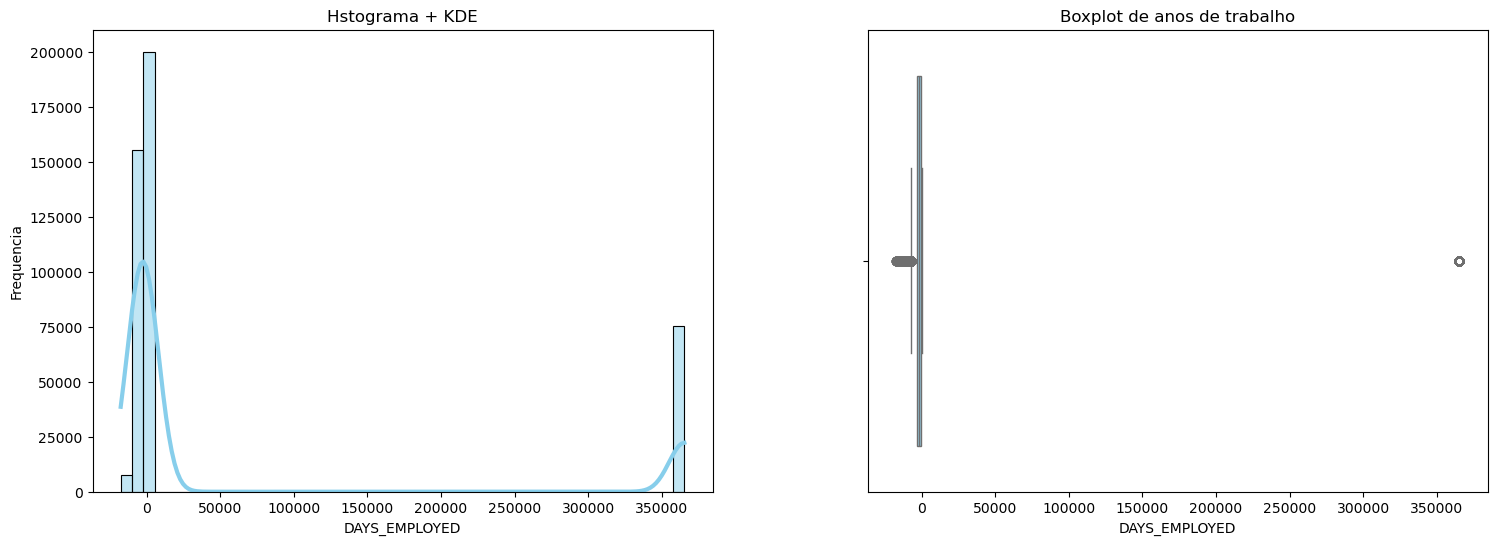

In [25]:
fig,axes = plt.subplots(1, 2, figsize = (18,6))
plt.subplots_adjust(wspace = 0.25) # ajuste so espaço entre os 2 gráficos

#criando coluna em anos para gerar o gráfico
anos_de_trabalho = df_application_record["DAYS_EMPLOYED"]

#Gráfico 1 Histograma + KDE
sns.histplot(
    x= anos_de_trabalho,
    kde=True,
    color = "skyblue",
    bins = 50,
    line_kws = {'linewidth':3, 'color':'darkblue'},
    ax = axes[0]
)
axes[0].set_title("Hstograma + KDE")
axes[0].set_xlabel("DAYS_EMPLOYED")
axes[0].set_ylabel("Frequencia")

#Gráfico 2 BOXPLOT
sns.boxplot(
    x = anos_de_trabalho,
    color = "skyblue",
    ax = axes[1]
)
axes[1].set_title('Boxplot de anos de trabalho')
axes[1].set_xscale('linear')
plt.show()

### Esse gráfico tá ruim de entender
melhoria do gráfico: tratar o outlier

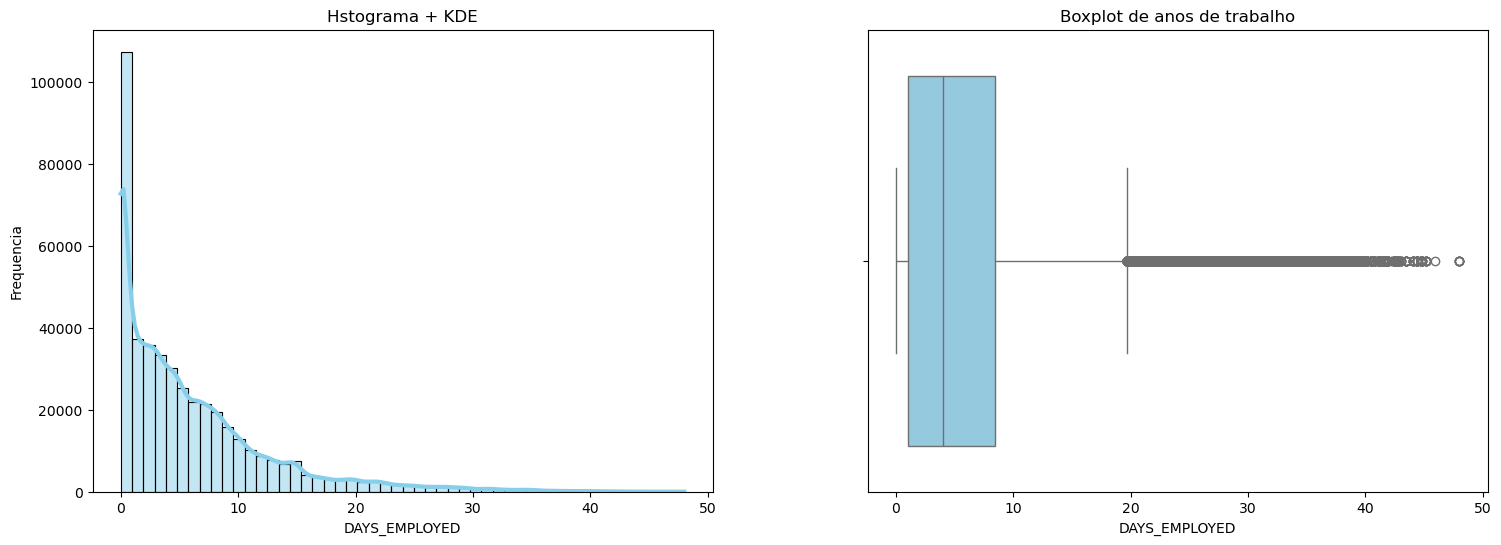

In [26]:
fig,axes = plt.subplots(1, 2, figsize = (18,6))
plt.subplots_adjust(wspace = 0.25) # ajuste so espaço entre os 2 gráficos


#Solução do problema: Tratar o valor de desempregado (365243) e convertemos dias negativos em anos positivos
anos_de_trabalho = df_application_record["DAYS_EMPLOYED"].apply(
    lambda x: -x / 365.25 if x < 0 else 0
)

#Gráfico 1 Histograma + KDE
sns.histplot(
    x= anos_de_trabalho,
    kde=True,
    color = "skyblue",
    bins = 50,
    line_kws = {'linewidth':3, 'color':'darkblue'},
    ax = axes[0]
)
axes[0].set_title("Hstograma + KDE")
axes[0].set_xlabel("DAYS_EMPLOYED")
axes[0].set_ylabel("Frequencia")

#Gráfico 2 BOXPLOT
sns.boxplot(
    x = anos_de_trabalho,
    color = "skyblue",
    ax = axes[1]
)
axes[1].set_title('Boxplot de anos de trabalho')
axes[1].set_xscale('linear')
plt.show()

### Analise primaria da coluna DAYS_EMPLOYED:
* **Forte presença de não-ativos:** Grande volume de clientes concentrados em 0 anos de trabalho (antigo código 365243), indicando desempregados/aposentados.
* **Perfil Jovem de Emprego:** A maior parte da população ativa possui menos de 7 anos no trabalho atual.
* **Outliers Saudáveis:** Presença de uma cauda longa de clientes com alta estabilidade (mais de 20 anos de serviço).

/tmp/ipykernel_40707/1792037506.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_40707/1792037506.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


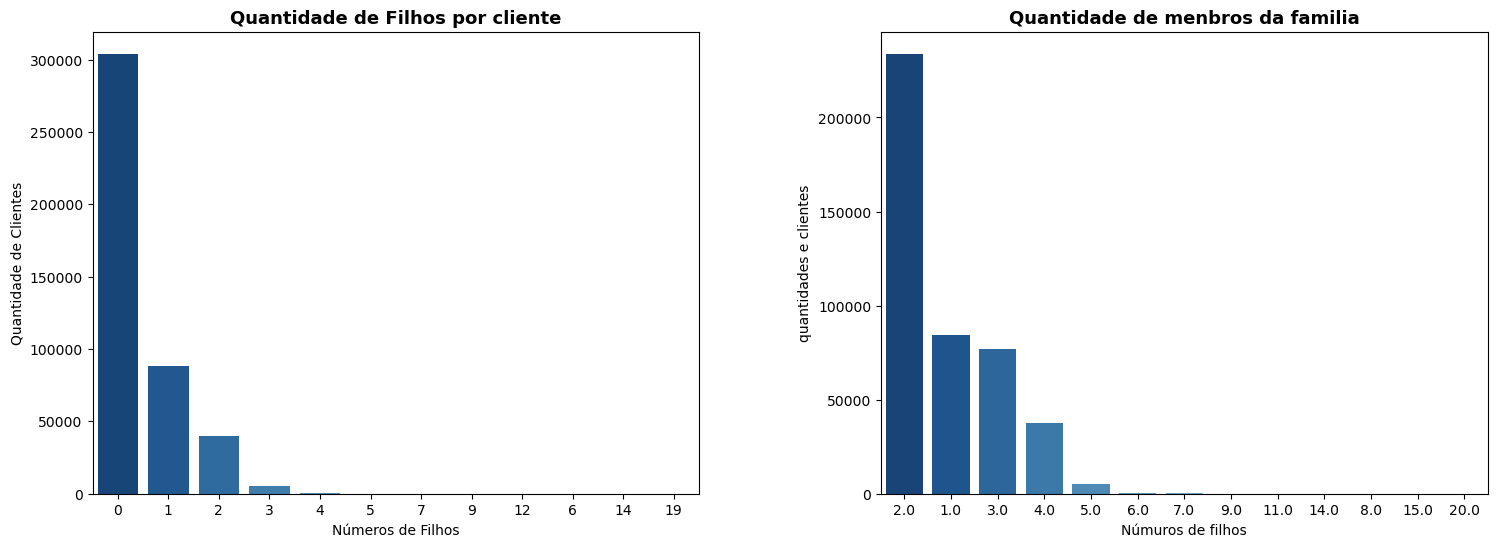

In [27]:
#configurando dois gráficos em um alinha
fig, axes = plt.subplots(1,2,figsize = (18,6))
plt.subplots_adjust(wspace = 0.3)#dessa vez um pouco mais afastado.

#Gráfico 1 variável discreta ( Quantidade de filhos) 
sns.countplot(
    data = df_application_record,
    x = "CNT_CHILDREN",
    palette = "Blues_r",
    ax = axes[0],
    order = df_application_record["CNT_CHILDREN"].value_counts().index
)
axes[0].set_title("Quantidade de Filhos por cliente", fontsize = 13, fontweight = "bold")
axes[0].set_xlabel("Números de Filhos")
axes[0].set_ylabel("Quantidade de Clientes")

##Gráfico 2 variável discreta ( Quantidade de membros familiasres) 
sns.countplot(
    data = df_application_record,
    x = "CNT_FAM_MEMBERS",
    palette="Blues_r",
    ax = axes[1],
    order = df_application_record["CNT_FAM_MEMBERS"].value_counts().index
)
axes[1].set_title("Quantidade de menbros da familia", fontsize = 13, fontweight="bold")
axes[1].set_xlabel("Númuros de filhos")
axes[1].set_ylabel("quantidades e clientes")

plt.show()

### Analise primaria da colunas [CNT_CHILDREN & CNT_FAM_MEMBERS] Estrutura Familiar
* **Perfil Sem Filhos:** A base de dados é composta majoritariamente por solicitantes sem filhos dependentes (moda = 0).
* **Núcleos Pequenos:** Predomínio de residências com 1 ou 2 membros totais (indivíduos sozinhos ou casais).
* **Forte Correlação:** As variáveis apresentam comportamento espelhado coerente. Necessário avaliar multicolinearidade na etapa de modelagem.


/tmp/ipykernel_40707/4171023938.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


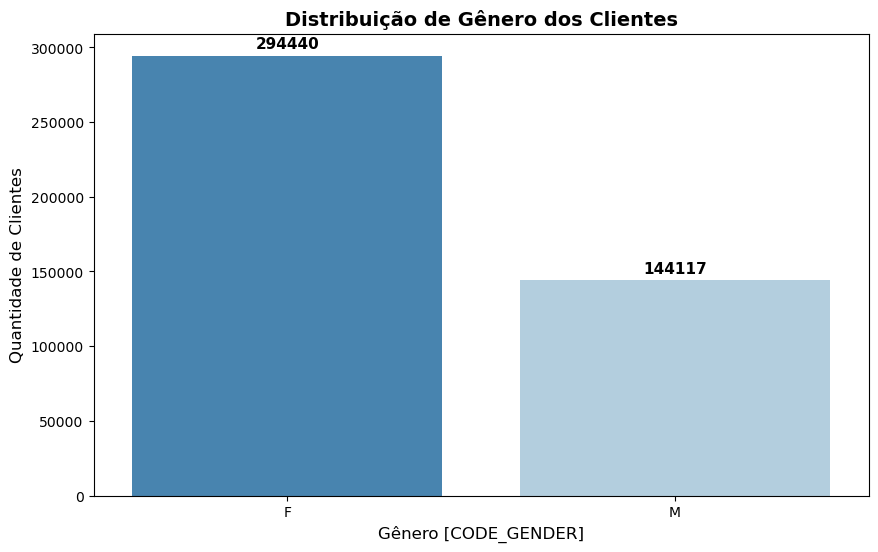

In [28]:
#Gráfico 1 Genero dos clientes(CODE_GENDER)

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data = df_application_record,
    x = "CODE_GENDER",
    palette = "Blues_r",
    order = df_application_record["CODE_GENDER"].value_counts().index
)
#olocando numeração nas barras
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, fontweight="bold", fmt='%d')


plt.title("Distribuição de Gênero dos Clientes", fontsize = 14, fontweight = "bold")
plt.xlabel("Gênero [CODE_GENDER]", fontsize = 12)
plt.ylabel("Quantidade de Clientes", fontsize =12)
           
plt.show()

#Gráfico 2 Tipo de Renda(NAME_INCOME_TYPE)

### Analise primaria da coluna Gênero dos Clientes (CODE_GENDER):
* **Predomínio Feminino:** A base de dados possui um forte desbalanceamento de gênero, com o público feminino representando aproximadamente 67% do volume total de clientes.
* **Volumetria Robusta:** Ambas as classes possuem representatividade massiva em termos absolutos (mais de 140 mil registros na menor classe), garantindo que o modelo linear ou de árvore consiga aprender os padrões de ambos os gêneros sem problemas de subamostragem.


NAME_INCOME_TYPE, NAME_EDUCATION_TYPE):

/tmp/ipykernel_40707/2630554743.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


Text(0, 0.5, 'Quantidade de C1lientes')

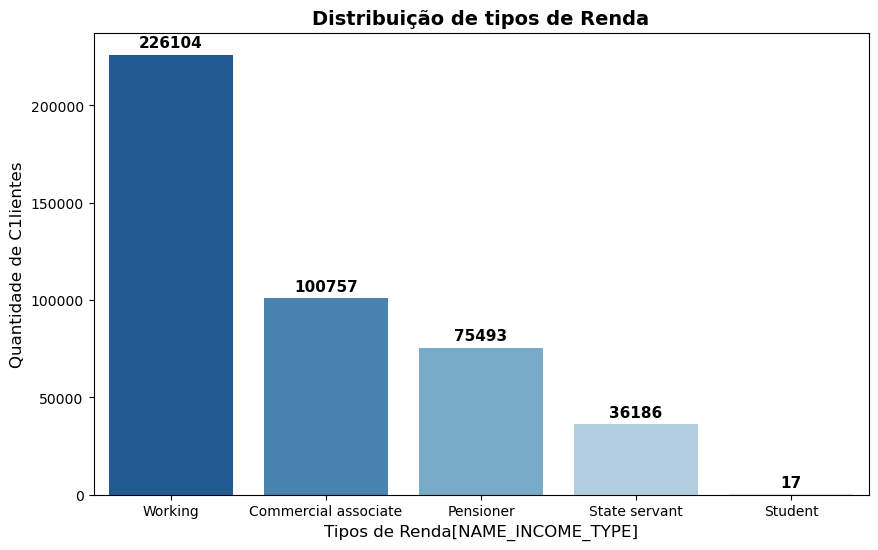

In [29]:
#Gráfico dos Tipos de Renda (NAME_INCOME_TYPE)
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data = df_application_record,
    x = "NAME_INCOME_TYPE",
    palette = "Blues_r",
    order = df_application_record["NAME_INCOME_TYPE"].value_counts().index
)
#colocando numeração nas barras
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize = 11, fontweight = "bold", fmt='%d')

plt.title("Distribuição de tipos de Renda", fontsize = 14, fontweight ="bold")
plt.xlabel("Tipos de Renda[NAME_INCOME_TYPE]", fontsize = 12)
plt.ylabel("Quantidade de C1lientes", fontsize = 12)

### Analise primaria da coluna  Tipo de Renda (NAME_INCOME_TYPE):
* **Concentração no Setor Privado:** Mais da metade da base ativa é composta por trabalhadores tradicionais (Working), seguidos por associados comerciais.
* **Estabilidade Relevante:** Aproximadamente 25% da base é composta por perfis de alta estabilidade financeira (Pensionistas e Servidores Públicos).
* **Atenção a Classes Raras:** A categoria 'Student' possui apenas 17 registros, necessitando de tratamento adequado (remoção ou agrupamento) na etapa de pré-processamento para evitar ruído no modelo.


/tmp/ipykernel_40707/1384492925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(


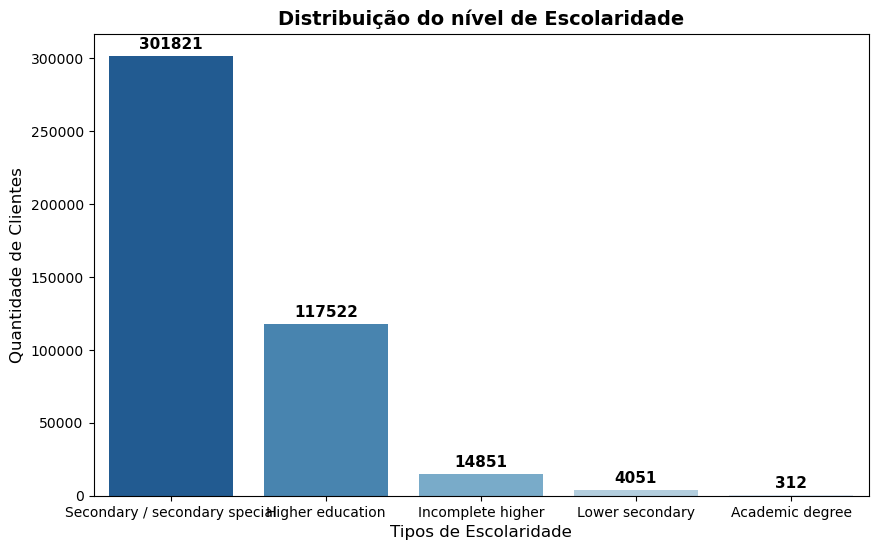

In [30]:
#Gráfico do tipo de nivel de escolaridade(NAME_EDUCATION_TYPE)
plt.figure(figsize=(10,6))

ax=sns.countplot(
    data = df_application_record,
    x = "NAME_EDUCATION_TYPE",
    palette = "Blues_r",
    order= df_application_record["NAME_EDUCATION_TYPE"].value_counts().index
)
#colocando numeração nas barras
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize = 11, fontweight = "bold", fmt='%d')

plt.title("Distribuição do nível de Escolaridade",fontsize = 14, fontweight="bold")
plt.xlabel("Tipos de Escolaridade",fontsize = 12)
plt.ylabel("Quantidade de Clientes",fontsize = 12)

plt.show()


### Analise primaria da coluna Tipo de Renda (NAME_INCOME_TYPE):
* **Concentração no Setor Privado:** Mais da metade da base ativa é composta por trabalhadores tradicionais (Working), seguidos por associados comerciais.
* **Estabilidade Relevante:** Aproximadamente 25% da base é composta por perfis de alta estabilidade financeira (Pensionistas e Servidores Públicos).
* **Atenção a Classes Raras:** A categoria 'Student' possui apenas 17 registros, necessitando de tratamento adequado (remoção ou agrupamento) na etapa de pré-processamento para evitar ruído no modelo.


### **Iniciando Com o dataframe df_credit_record**

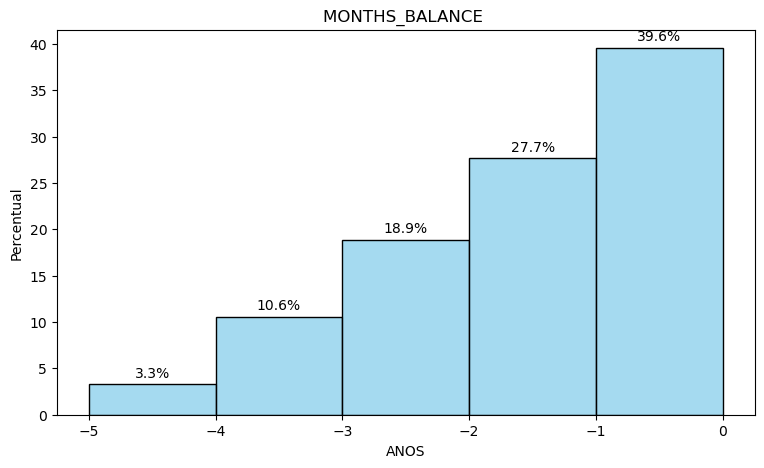

In [31]:
#Configurando o tamanho da imagem
plt.figure(figsize=(9,5))

#Plota o histograma 
ax = sns.histplot( #<= importante colocar o gréfico em uma variavel
    data = df_credit_record,
    x= df_credit_record["MONTHS_BALANCE"]/12,
    stat="percent",
    color="skyblue",
    edgecolor="black",
    bins=5,
)
# Adiciona o número certo em cima de cada coluna
for container in ax.containers:
    # 'fmt="%.1f%%"' mostra 1 casa decimail.Para represenar as porcentagens
    ax.bar_label(container, padding=3, fontsize=10, fmt="%.1f%%")

plt.title("MONTHS_BALANCE ")
plt.xlabel("ANOS")
plt.ylabel("Percentual")
plt.show()

### Analise primaria da coluna MONTHS_BALANCE
O gráfico apresenta a distribuição histórica dos dados na variável **'MONTHS_BALANCE'** ao longo de cinco anos.  
Olhando cronologicamente do passado para o presente, observa-se que o volume de registros cresce de forma contínua: 
os dados mais antigos, de cinco anos atrás, representam apenas **3,3%** do dataset, seguidos por **10,6%** no quarto ano, 18,9% no terceiro ano, 27,7% no segundo até atingir o ápice de 39,6% no ano mais recente (primeiro ano). Esse crescimento progressivo à medida que nos aproximamos do presente sugere a implementação bem-sucedida de uma cultura empresarial orientada a dados (data-driven), ou uma evolução gradativa no comportamento de usuários e funcionários em relação ao registro de informações.

/tmp/ipykernel_40707/2799126458.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(#<= importante salvar o gráfico em uma variável 'ax'


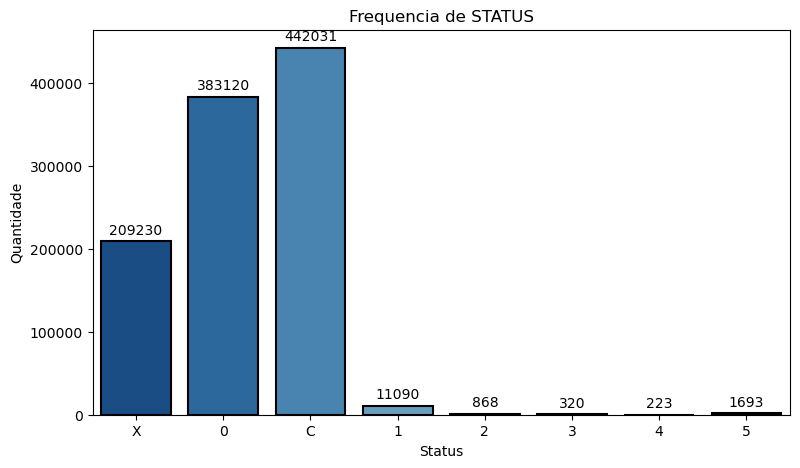

In [32]:
#Configurando o tamanha da imagem
plt.figure(figsize=(9,5))

#Cria o gráfico de barras de contagem
ax = sns.countplot(#<= importante salvar o gráfico em uma variável 'ax'
    data = df_credit_record,
    x = df_credit_record["STATUS"].astype(str),
    palette ="Blues_r",
    edgecolor ="black",
    linewidth = 1.5,
)

# adicionar os valores em cima das colunas
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
    
plt.title("Frequencia de STATUS")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.show()

### Analise primaria da coluna STATUS  
A análise do histórico de crédito abrange um total de 1.048.575 registros mensais, revelando um cenário financeiro majoritariamente saudável e de baixo risco estrutural.  
**Pontualidade:** O maior volume concentra-se em clientes com as contas totalmente pagas ou em dia, somando 442.031 registros (42,16% do total).  
**Atrasos mínimos:** Outra parcela expressiva, de 382.120 registros (36,44%), apresenta atrasos curtos de no máximo 30 dias, refletindo flutuações temporárias comuns no fluxo de caixa dos consumidores.  
**Inatividade:** Por fim, 209.230 registros (19,95%) correspondem a períodos sem nenhuma operação de crédito ou empréstimo ativa no mês.  
*Em resumo, mais de 78% da base de dados opera dentro da normalidade ou com atrasos irrelevantes para o risco de crédito de longo prazo.*

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

Text(0.5, 1.0, 'Correlação df_credit_sore')

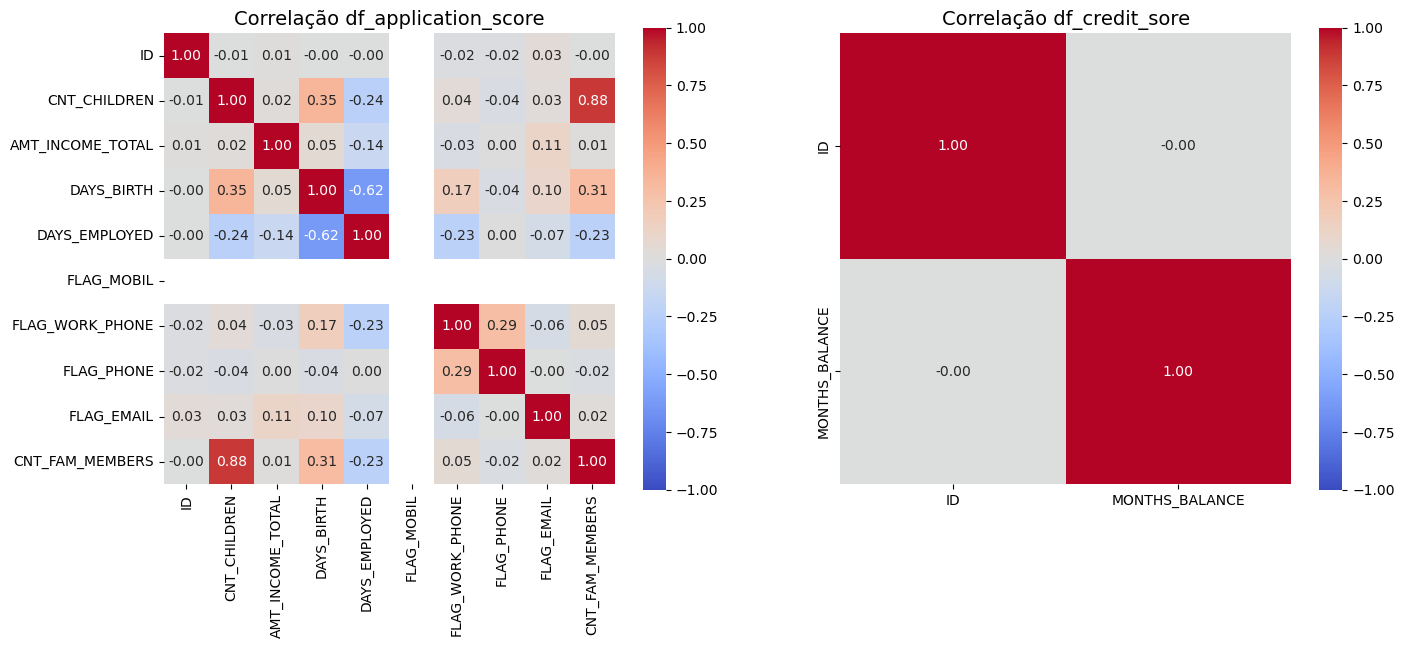

In [33]:
# heatmap de correlação
#Criando a estrutura com 2 gráficos lado a lado
fig, axes = plt.subplots(1,2, figsize = (16,6))

# calculando a matriz de correlaçaõ de cada um
corr_df_application_record = df_application_record.corr(numeric_only = True)
corr_df_credit_record = df_credit_record.corr(numeric_only = True)

#headmap do Dataset 1 
sns.heatmap(
    corr_df_application_record, 
    ax = axes[0], 
    cmap = 'coolwarm', 
    vmin = -1, 
    vmax = 1, 
    annot = True,
    fmt = ".2f",
    square = True)
axes[0].set_title('Correlação df_application_score',fontsize=14)

#hadmap do Dataset 2
sns.heatmap(
    corr_df_credit_record,
    ax = axes[1],
    cmap ='coolwarm',
    vmin = -1,
    vmax = 1,
    annot = True,
    fmt = ".2f",
    square = True)
axes[1].set_title('Correlação df_credit_sore', fontsize = 14)

### Esse gráfico tá ruim de entender
melhoria do gráfico:tratar as variaveis que são binárias para ter um heatmap completoe fazer o heatmap de somente um dataset.

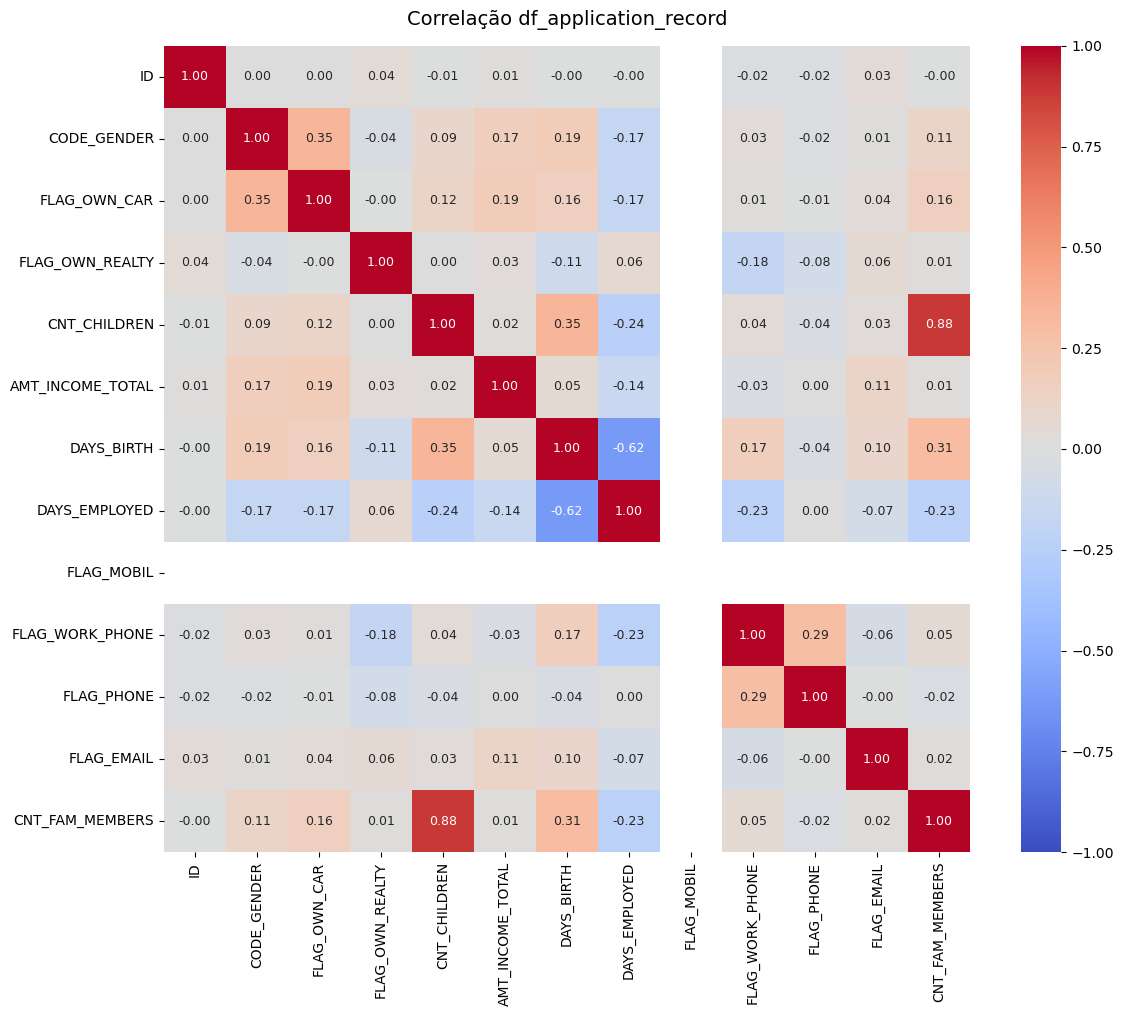

In [34]:
# Criando uma cópia temporária para proteger dos dados originais
df_application_record_heatmap_com_binarios = df_application_record

#definindo os dicionarios de mapeamento
map_gender = {'M':1,'F':0}         
map_yes_no = {'Y':1,'N':0}                    

#.Aplicando as transformações apenas na cópia temporária
df_application_record_heatmap_com_binarios['CODE_GENDER'] = df_application_record['CODE_GENDER'].map(map_gender).astype('Int64')
df_application_record_heatmap_com_binarios['FLAG_OWN_CAR'] = df_application_record['FLAG_OWN_CAR'].map(map_yes_no).astype('Int64')
df_application_record_heatmap_com_binarios['FLAG_OWN_REALTY'] = df_application_record['FLAG_OWN_REALTY'].map(map_yes_no).astype('Int64')

#Calculando a matriz da correlação
corr_df_application_record_heatmap_com_binarios = df_application_record_heatmap_com_binarios.corr(numeric_only = True)

#Criando estrutura de um gráfico(Ajustando o tamanho para caber tudo)
plt.figure(figsize=(12,10))

#Gerando o heatmap(Com fontes menores para garantir a leitura)

sns.heatmap(
    corr_df_application_record_heatmap_com_binarios,
    cmap = 'coolwarm',
    vmin = -1,
    vmax = 1,
    annot = True,
    fmt = ".2f",
    annot_kws={"size":9},
    square = True
)

plt.title('Correlação df_application_record', fontsize = 14, pad = 15)
plt.tight_layout()
plt.show()

### Analise primaria da correlação do daaset df_application_record
#### **Novas Variáveis Convertidas**
**CODE_GENDER vs AMT_INCOME_TOTAL** *(0.17)*: Mostra uma correlação positiva leve. Considerando que Masculino foi mapeado como 1 e Feminino como 0, o gráfico aponta que, nesta base de dados específica, os homens possuem uma leve tendência a declarar rendimentos anuais maiores.  

**CODE_GENDER vs DAYS_EMPLOYED** *(-0.17)*: Há uma correlação negativa leve. Isso indica uma dinâmica diferente no tempo de emprego declarado entre os gêneros na base.

**FLAG_OWN_CAR vs AMT_INCOME_TOTAL** *(0.03)*: A correlação é praticamente nula. Indivíduos que possuem carro próprio (Y mapeado como 1) não apresentam necessariamente uma renda anual declarada maior do que quem não possui.

**CODE_GENDER vs FLAG_OWN_CAR** *(0.35)*: Existe uma correlação positiva moderada.Insight: Assumindo que Masculino foi mapeado como 1 e Feminino como 0, há uma tendência estatística na base de que clientes do gênero masculino possuem carro com mais frequência do que as clientes do gênero feminino.

**CODE_GENDER vs AMT_INCOME_TOTAL** *(0.17)* e FLAG_OWN_CAR (0.19)*:
Insight: O gênero masculino (1) e a posse de carro próprio têm uma correlação levemente positiva com o rendimento anual total. Clientes que possuem carro declaram rendas ligeiramente mais altas.

**FLAG_OWN_REALTY (Imóvel próprio)**: Possuir imóvel próprio tem correlações quase nulas ou ligeiramente negativas com o resto do dataset (ex: -0.11 com DAYS_BIRTH).Insight: Ter casa própria não está associado a ter mais renda ou mais filhos nesta base, mas tem uma leve relação com pessoas de idades específicas.

##### **Estrutura Familiar e Ciclo de Vida**
**CNT_CHILDREN vs CNT_FAM_MEMBERS** *(0.88)*: Esta é a correlação positiva mais forte do gráfico. Ela confirma de forma lógica que o número de filhos dita quase perfeitamente o tamanho total do núcleo familiar do cliente.

**DAYS_BIRTH vs CNT_CHILDREN** *(0.35)*: Como DAYS_BIRTH armazena a idade em dias regressivos (valores negativos), números maiores (menos negativos) representam pessoas mais jovens. Portanto, essa correlação positiva de 0.35 indica que os clientes mais jovens da base possuem mais filhos registrados no cadastro.

#### **Histórico Profissional e Idade**
**DAYS_EMPLOYED vs DAYS_BIRTH** *(-0.62)*: Existe uma correlação negativa moderada a forte. Como ambas as variáveis são medidas em dias negativos (regressivos), esse valor indica consistência biológica e profissional: quanto mais velha a pessoa é (DAYS_BIRTH mais negativo), maior tende a ser o seu tempo de emprego (DAYS_EMPLOYED também mais negativo).

#### **Meios de Contato**
**FLAG_WORK_PHONE vs FLAG_PHONE** *(0.29)*: Existe uma correlação positiva leve entre fornecer o telefone comercial e o telefone fixo residencial. Quem fornece um tipo de contato fixo alternativo tem mais propensão a fornecer o outro.

#### **Qualidade dos Dados e Limpeza**
**A linha em branco (FLAG_MOBIL):** A variável FLAG_MOBIL gerou uma faixa vazia no gráfico. Isso significa que 100% dos clientes possuem o mesmo valor nessa coluna (todos informaram possuir celular). Como não há variância, a correlação matemática é nula.  
*Ação*: Ela deve ser removida antes de qualquer modelagem, pois não adiciona poder preditivo.


## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

In [35]:
# detecção de outliers

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

In [36]:
df[TARGET].value_counts(normalize=True)

NameError: name 'df' is not defined

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._